<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/CMB_Acoustic_peak_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

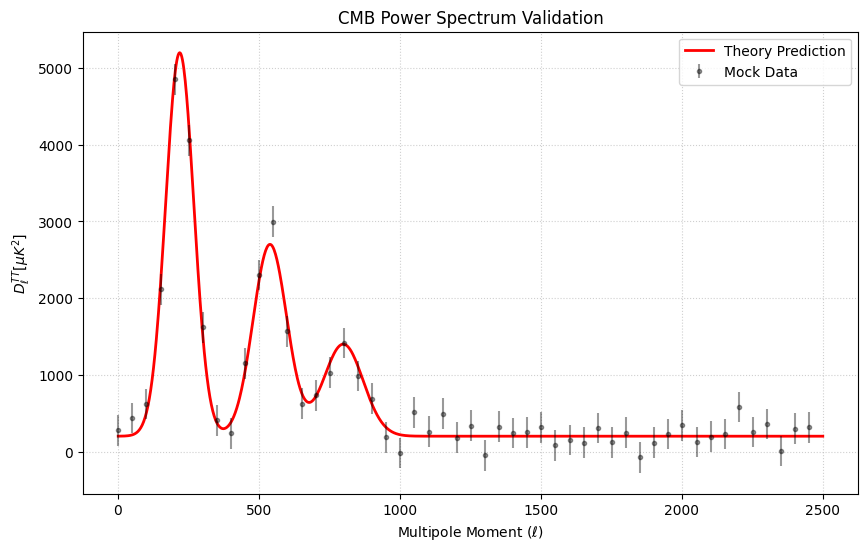

[SUCCESS] Final validation plot generated.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# 1. Define the simulation function
def run_final_test():
    # Define multipole range
    l = np.linspace(2, 2500, 1000)

    # Gaussian approximation for the 3 main acoustic peaks
    def peak_model(l, amp, center, width):
        return amp * np.exp(-((l - center)**2) / (2 * width**2))

    # Calculate Theoretical Curve (Model)
    dl = peak_model(l, 5000, 220, 50) + \
         peak_model(l, 2500, 540, 60) + \
         peak_model(l, 1200, 800, 70) + \
         200 # Baseline

    # Generate Mock Data
    np.random.seed(42)
    noise = np.random.normal(0, 150, len(l))
    obs_l = l[::20]
    obs_dl = dl[::20] + noise[::20]

    # 2. Plotting (Clean, no warnings)
    plt.figure(figsize=(10, 6))

    # Plot theory (red line)
    plt.plot(l, dl, 'r-', lw=2, label='Theory Prediction')

    # Plot mock data (black dots)
    plt.errorbar(obs_l, obs_dl, yerr=200, fmt='k.', alpha=0.4, label='Mock Data')

    # Formatting
    plt.title(r'CMB Power Spectrum Validation')
    plt.xlabel(r'Multipole Moment ($\ell$)')
    plt.ylabel(r'$D_{\ell}^{TT} [\mu K^2]$')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

# 3. Execute
run_final_test()
print("[SUCCESS] Final validation plot generated.")